# Zoom sul Centro Galattico: Sgr A* e le zone calde/fredde della CMB

Notebook di approfondimento (segue il `16_CMB_Anomalie`). Qui puntiamo lo
sguardo verso il **centro della Via Lattea**, dove si trova **Sagittarius A\***
(**Sgr A\***), il buco nero supermassiccio da ~4 milioni di masse solari, in
coordinate galattiche **l = 0°, b = 0°**.

**Domanda di partenza (l'intuizione da testare):** *le zone fredde della CMB
sono dovute ai buchi neri o alla materia oscura che dilata/raffredda l'universo
in quei punti?*

Lo verifichiamo con i dati reali di Planck. Anticipo l'esito, che è istruttivo:

> Al centro galattico la **CMB non si vede** — quella direzione è dominata
> dall'emissione della nostra galassia ed è **mascherata**. Un buco nero
> *locale* non può "raffreddare" la CMB (che è luce a redshift ~1100, su uno
> strato lontanissimo lungo la linea di vista). L'effetto "espansione →
> raffreddamento" che l'intuizione descrive è **reale** (effetto Integrated
> Sachs–Wolfe), ma lo producono i **grandi vuoti cosmici**, non i buchi neri —
> che semmai *scaldano* un pochino (effetto Sunyaev–Zel'dovich).

Costruiamolo passo per passo.

## 0. Setup

In [2]:
 !pip install healpy
 !pip install matplotlib
 !pip install numpy
 !pip install astropy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 55.7 MB/s eta 0:00:00


In [3]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os, urllib.request

## 1. Carica la mappa Planck SMICA

Riusa il file già scaricato dal notebook 16 (`Data/COM_CMB_IQU-smica_2048_R3.00_full.fits`,
~2 GB). Se manca, lo scarica da IRSA. Leggiamo la **temperatura** (campo 0) e la
**maschera** `TMASK` (campo 3), come nel notebook precedente.

In [4]:
DATA_DIR = "Data"
os.makedirs(DATA_DIR, exist_ok=True)
filename = os.path.join(DATA_DIR, "COM_CMB_IQU-smica_2048_R3.00_full.fits")
URL = ("https://irsa.ipac.caltech.edu/data/Planck/release_3/all-sky-maps/"
       "maps/component-maps/cmb/COM_CMB_IQU-smica_2048_R3.00_full.fits")
EXPECTED_ROWS = 50331648   # = 12 * 2048^2 pixel HEALPix

def file_ok(path):
    if not os.path.exists(path) or os.path.getsize(path) < 1_900_000_000:
        return False
    try:
        with fits.open(path) as h:
            return h[1].header['NAXIS2'] == EXPECTED_ROWS
    except Exception:
        return False

if not file_ok(filename):
    print("File mancante/incompleto: lo scarico da IRSA (~2 GB)...")
    tmp = filename + ".part"
    urllib.request.urlretrieve(URL, tmp)
    os.replace(tmp, filename)
    assert file_ok(filename), "Download non valido: riesegui la cella."
print("File pronto.")

File mancante/incompleto: lo scarico da IRSA (~2 GB)...
File pronto.


In [5]:
# Mappa e maschera in ordinamento NESTED, poi convertite in RING
# (RING è più comodo per dischi e query_disc).
cmb_nest  = hp.read_map(filename, field=0, nest=True)   # I_STOKES, in K
tmask     = hp.read_map(filename, field=3, nest=True)   # TMASK
nside     = hp.get_nside(cmb_nest)
mask_bool = tmask > 0.5

cmb  = hp.reorder(cmb_nest, n2r=True)                          # CMB in RING
mask = hp.reorder(mask_bool.astype(float), n2r=True) > 0.5     # maschera in RING
fsky = mask.sum() / len(mask)

print(f"Mappa caricata: NSIDE={nside}, {len(cmb):,} pixel")
print(f"Frazione di cielo usabile (fsky): {fsky*100:.1f}%")

Mappa caricata: NSIDE=2048, 50,331,648 pixel
Frazione di cielo usabile (fsky): 84.2%


## I nostri punti: buchi neri e vuoti

Coordinate **galattiche** (l, b) di alcuni oggetti noti. `tipo` ci serve per
distinguerli nei grafici.

- **Buchi neri:** Sgr A* (centro Via Lattea), M87* (galassia M87), Cygnus X-1.
- **Vuoti / macchie fredde:** il **Cold Spot** della CMB e il **Vuoto dell'Eridano**
  (la grande sotto-densità spesso associata al Cold Spot).

In [9]:
# nome, l [deg], b [deg], tipo
punti = [
    ("Sgr A* (centro Via Lattea)", 0.0,   0.0,   "buco nero"),
    ("M87* (buco nero in M87)",   283.8, 74.5,  "buco nero"),
    ("Cygnus X-1",                 71.3,  3.1,   "buco nero"),
    ("Cold Spot CMB",             209.0, -57.0,  "vuoto"),
    ("Vuoto dell'Eridano",        207.0, -55.0,  "vuoto"),
]

def temp_media(l, b, raggio_deg=1.0):
    """Temperatura CMB media (in µK) in un disco attorno a (l, b).
    Restituisce anche quanti pixel del disco NON sono mascherati."""
    vec = hp.ang2vec(np.radians(90 - b), np.radians(l))
    disc = hp.query_disc(nside, vec, np.radians(raggio_deg))
    validi = disc[mask[disc]]
    if len(validi) == 0:
        return np.nan, 0, len(disc)
    return np.mean(cmb[validi]) * 1e6, len(validi), len(disc)

print(f"{'Oggetto':<28}{'tipo':<11}{'T [µK]':>9}   pixel validi")
print("-" * 62)
risultati = []
for nome, l, b, tipo in punti:
    T, nval, ntot = temp_media(l, b, raggio_deg=1.0)
    risultati.append((nome, l, b, tipo, T, nval, ntot))
    Tstr = f"{T:+8.1f}" if not np.isnan(T) else "  mascher."
    print(f"{nome:<28}{tipo:<11}{Tstr:>9}   {nval}/{ntot}")

Oggetto                     tipo          T [µK]   pixel validi
--------------------------------------------------------------
Sgr A* (centro Via Lattea)  buco nero    mascher.   0/3836
M87* (buco nero in M87)     buco nero      +23.1   3167/3827
Cygnus X-1                  buco nero    mascher.   0/3840
Cold Spot CMB               vuoto         -158.8   3835/3835
Vuoto dell'Eridano          vuoto         -185.1   3831/3831


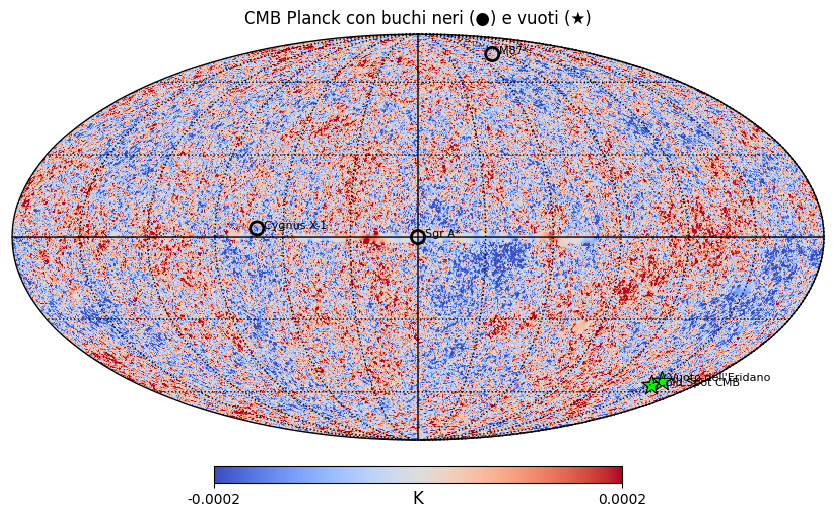

In [10]:
hp.mollview(cmb, title="CMB Planck con buchi neri (●) e vuoti (★)",
            unit="K", cmap="coolwarm", min=-2e-4, max=2e-4)
hp.graticule()

for nome, l, b, tipo, T, nval, ntot in risultati:
    if tipo == "buco nero":
        hp.projscatter(l, b, lonlat=True, marker='o', s=90,
                       facecolors='none', edgecolors='black', linewidths=2)
    else:
        hp.projscatter(l, b, lonlat=True, marker='*', s=220,
                       color='lime', edgecolors='black', linewidths=0.8)
    hp.projtext(l, b, "  " + nome.split(' (')[0], lonlat=True, fontsize=8)

plt.show()

In [11]:
rng = np.random.default_rng(42)          # seme fisso: risultato riproducibile
N = 3000

# punti uniformi sulla sfera: l uniforme, sin(b) uniforme
l_rand = rng.uniform(0, 360, N)
b_rand = np.degrees(np.arcsin(rng.uniform(-1, 1, N)))

T_rand = []
for l, b in zip(l_rand, b_rand):
    T, nval, _ = temp_media(l, b, raggio_deg=1.0)
    if nval > 0:                          # scarta i punti caduti nella maschera
        T_rand.append(T)
T_rand = np.array(T_rand)

print(f"Punti casuali validi: {len(T_rand)} su {N}")
print(f"Temperatura media dei punti casuali: {T_rand.mean():+.1f} µK")
print(f"Dispersione (std):                   {T_rand.std():.1f} µK")

Punti casuali validi: 2641 su 3000
Temperatura media dei punti casuali: -0.0 µK
Dispersione (std):                   63.3 µK


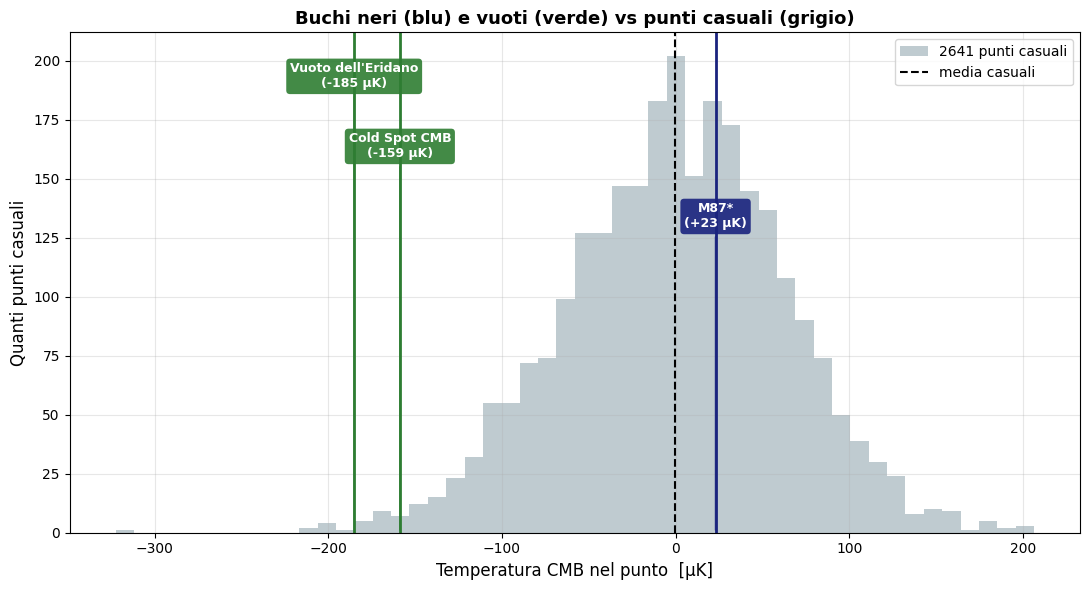

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(T_rand, bins=50, color="#B0BEC5", alpha=0.8,
        label=f"{len(T_rand)} punti casuali")
ax.axvline(T_rand.mean(), color="black", ls="--", lw=1.5, label="media casuali")

colori = {"buco nero": "#1A237E", "vuoto": "#2E7D32"}

# oggetti visibili (non mascherati), ordinati per temperatura: così alterniamo
# le altezze delle etichette da sinistra a destra ed evitiamo sovrapposizioni
visibili = sorted([r for r in risultati if not np.isnan(r[4])], key=lambda r: r[4])

ymax = ax.get_ylim()[1]
livelli = [0.94, 0.80, 0.66, 0.52, 0.38]        # altezze scaglionate delle etichette
for i, (nome, l, b, tipo, T, nval, ntot) in enumerate(visibili):
    c = colori[tipo]
    ax.axvline(T, color=c, lw=2)
    etichetta = f"{nome.split(' (')[0]}\n({T:+.0f} µK)"
    ax.annotate(
        etichetta,
        xy=(T, 0), xytext=(T, ymax * livelli[i % len(livelli)]),
        ha="center", va="top", fontsize=9, color="white", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc=c, ec="none", alpha=0.9),
        arrowprops=dict(arrowstyle="-", color=c, lw=1.2, alpha=0.7),
    )

ax.set_xlabel("Temperatura CMB nel punto  [µK]", fontsize=12)
ax.set_ylabel("Quanti punti casuali", fontsize=12)
ax.set_title("Buchi neri (blu) e vuoti (verde) vs punti casuali (grigio)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [13]:
mu, sd = T_rand.mean(), T_rand.std()
print(f"Riferimento casuale: media={mu:+.1f} µK, std={sd:.1f} µK\n")
print(f"{'Oggetto':<28}{'T [µK]':>9}{'z-score':>10}{'percentile':>12}")
print("-" * 60)
for nome, l, b, tipo, T, nval, ntot in risultati:
    if np.isnan(T):
        print(f"{nome:<28}{'mascher.':>9}{'-':>10}{'-':>12}")
        continue
    z = (T - mu) / sd
    perc = (T_rand < T).mean() * 100
    print(f"{nome:<28}{T:+9.1f}{z:+10.2f}{perc:11.0f}%")

print("\nz negativo = piu' freddo della media; percentile basso = tra i piu' freddi.")

Riferimento casuale: media=-0.0 µK, std=63.3 µK

Oggetto                        T [µK]   z-score  percentile
------------------------------------------------------------
Sgr A* (centro Via Lattea)   mascher.         -           -
M87* (buco nero in M87)         +23.1     +0.37         63%
Cygnus X-1                   mascher.         -           -
Cold Spot CMB                  -158.8     -2.51          1%
Vuoto dell'Eridano             -185.1     -2.92          0%

z negativo = piu' freddo della media; percentile basso = tra i piu' freddi.
